In [2]:
!pip install ultralytics

In [3]:
from ultralytics import YOLO

In [7]:
DATA_YEML = "construction-ppe.yaml"

MODEL_BASE = "yolov8n.pt"

In [8]:
model = YOLO(MODEL_BASE)

In [10]:
model.train(data=DATA_YEML, epochs=10, imgsz=640, batch=16, patience=3, project="runs/detect", name="yolo_const")

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=construction-ppe.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_const, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=3, perspective=0.0,

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ee9c47f71a0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.

In [11]:
best = YOLO("runs/detect/runs/detect/yolo_const/weights/best.pt")

In [38]:
metrics = best.val()

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 651.0±858.8 MB/s, size: 132.2 KB)
val: Scanning /content/datasets/construction-ppe/labels/val.cache... 143 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 143/143 28.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 2.1it/s 4.3s0.2ss
                   all        143       1172        0.7      0.518       0.55       0.27
                helmet        107        201      0.751      0.826      0.787      0.416
                gloves         68        136      0.771      0.721      0.774      0.367
                  vest        109        171      0.687      0.819      0.833       0.49
                 boots         64        151      0.638      0.788      0.801      0.458
               goggles         44         47      0.626      0.723      0.752      0.331
                  non

In [13]:
import cv2
import matplotlib.pyplot as plt
import pathlib
import os

In [31]:
pred = best.predict(
    source="https://www.worldconstructiontoday.com/wp-content/uploads/news/16023/Construction-Workers.jpg",
    conf=0.25,
    save=True
)


WARNING ⚠️ Download failure, retrying 1/3 https://www.worldconstructiontoday.com/wp-content/uploads/news/16023/Construction-Workers.jpg... HTTP Error 403: Forbidden
image 1/1 /content/Construction-Workers.jpg: 384x640 4 helmets, 1 vest, 2 nones, 3 Persons, 77.2ms
Speed: 4.0ms preprocess, 77.2ms inference, 2.3ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/detect/predict2


In [40]:
!ls

105420523-1535475566932civilengineer.jpg
360_F_593408229_iZUqIkNJTnfcej66N5oWm38uFgX5AoYl.jpg
bus.jpg
Construction-Workers.jpg
datasets
runs
sample_data
stickers-construction-worker.jpg.jpg
women-in-construction-1.jpg
yolo26n.pt
yolov8n.pt


In [32]:
save_dir=pathlib.Path(pred[0].save_dir)

In [33]:
out_img = next(save_dir.glob("Construction-Workers.jpg"))

In [34]:
img = cv2.cvtColor(cv2.imread(str(out_img)), cv2.COLOR_BGR2RGB)

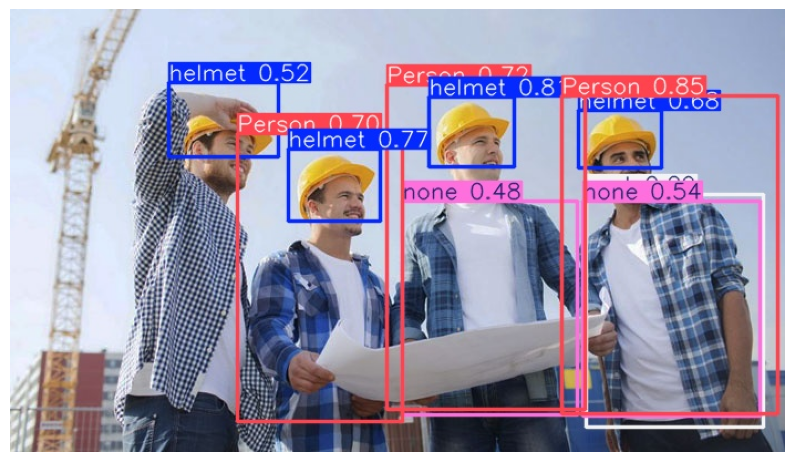

In [35]:
plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
best.export(format="onnx")

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from 'runs/detect/runs/detect/yolo_const/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 15, 8400) (6.0 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 177ms
Prepared 4 packages in 3.99s
Installed 4 packages in 360ms
 + colorama==0.4.6
 + onnx==1.20.1
 + onnxruntime-gpu==1.24.2
 + onnxslim==0.1.86

requirements: AutoUpdate success ✅ 5.5s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.20.1 opset 22...


/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/utils.py:552: OnnxExporterWarning: Exporting to ONNX opset version 22 is not supported. by 'torch.onnx.export()'. The highest opset version supported is 20. To use a newer opset version, consider 'torch.onnx.export(..., dynamo=True)'. 
  _export(


ONNX: slimming with onnxslim 0.1.86...
ONNX: export success ✅ 7.4s, saved as 'runs/detect/runs/detect/yolo_const/weights/best.onnx' (11.7 MB)

Export complete (8.0s)
Results saved to /content/runs/detect/runs/detect/yolo_const/weights
Predict:         yolo predict task=detect model=runs/detect/runs/detect/yolo_const/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=runs/detect/runs/detect/yolo_const/weights/best.onnx imgsz=640 data=/usr/local/lib/python3.12/dist-packages/ultralytics/cfg/datasets/construction-ppe.yaml  
Visualize:       https://netron.app


'runs/detect/runs/detect/yolo_const/weights/best.onnx'

In [39]:

print(f"mAP@50: {metrics.box.map50}") 
print(f"Precision: {metrics.box.mp}") 
print(f"Recall: {metrics.box.mr}")

mAP@50: 0.5500072497596307
Precision: 0.7003790111901356
Recall: 0.5184510360405032
